In [ ]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 1. Loading and Preprocessing
# Load dataset
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

# Handle missing values (check)
print(f"Missing values:\n{df.isnull().sum()}\n")

# Feature Scaling
X = df.drop('MedHouseVal', axis=1)
y = df['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Preprocessing Explanation:
# Standardization (StandardScaler) is necessary because algorithms like SVR and Linear Regression
# are sensitive to the scale of features. It ensures all features contribute equally to the distance metrics.

# 2. Regression Algorithm Implementation
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "SVR": SVR(kernel='rbf')
}

results = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    # Predict
    predictions = model.predict(X_test_scaled)
    # Evaluate
    mse = mean_squared_error(y_test, predictions)
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    results[name] = [mse, mae, r2]

# 3. Model Evaluation and Comparison
results_df = pd.DataFrame(results, index=['MSE', 'MAE', 'R2']).T
print("Model Evaluation Summary:")
print(results_df)

# Comparisons
best_model = results_df['R2'].idxmax()
worst_model = results_df['R2'].idxmin()

print(f"\nBest Performing Model: {best_model} (Highest R2)")
print(f"Worst Performing Model: {worst_model} (Lowest R2)")

# Brief Explanations (Summary for Assignment):
# Linear Regression: Finds a linear relationship; simple but assumes linearity.
# Decision Tree: Splits data into branches; handles non-linear patterns but prone to overfitting.
# Random Forest: Ensemble of trees; reduces overfitting and increases accuracy.
# Gradient Boosting: Builds trees sequentially to correct errors; often highest performance.
# SVR: Uses kernels to find hyperplanes in high dimensions; robust to outliers."

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

Model Evaluation Summary:
                        MSE       MAE        R2
Linear Regression  0.555892  0.533200  0.575788
Decision Tree      0.493969  0.453904  0.623042
Random Forest      0.255170  0.327425  0.805275
Gradient Boosting  0.293999  0.371650  0.775643
SVR                0.357004  0.398599  0.727563

Best Performing Model: Random Forest (Highest R2)
Worst Performing Model: Linear Regression (Lowest R2)


/tmp/ipykernel_3877/1929078748.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y='R2', data=results_df, palette='viridis')


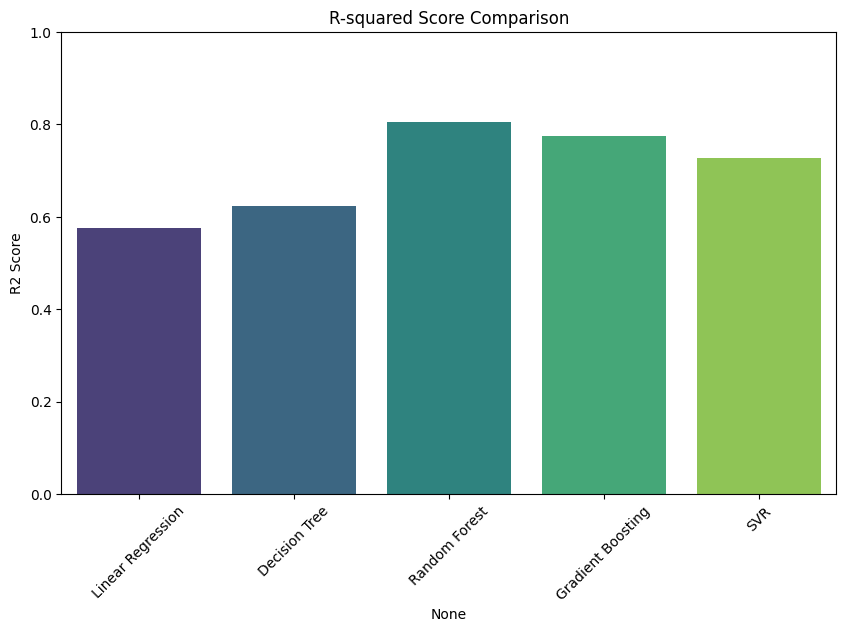

Justification: The Random Forest performed best because it effectively handles complex non-linear relationships and interactions between features through its ensemble approach.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the R2 Scores for comparison
plt.figure(figsize=(10, 6))
sns.barplot(x=results_df.index, y='R2', data=results_df, palette='viridis')
plt.title('R-squared Score Comparison')
plt.ylabel('R2 Score')
plt.ylim(0, 1)
plt.xticks(rotation=45)
plt.show()

print(f"Justification: The {best_model} performed best because it effectively handles complex non-linear relationships and interactions between features through its ensemble approach.")